## Init

In [165]:

from math import exp
from turtle import color

from pyparsing import line
from plot2D import CVSPlot
from scipy.optimize import curve_fit
from cycler import cycler
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

# Directory Management
try:
    # Run in Terminal
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
except:
    # Run in ipykernel & interactive
    ROOT_DIR = os.getcwd()

def getColorTuple(r,g,b):
    return (r/255, g/255, b/255)

color_list = [getColorTuple(144,201,231),
              getColorTuple(33,158,188),
              getColorTuple(19,103,131),
              getColorTuple(254,183,5),
              getColorTuple(255,158,2),
              getColorTuple(255,134,0)]

config = {
    'font.family': 'serif',
    "mathtext.fontset": 'stix',
    "font.serif":['SimSun'],
    "font.size": 18,
    'axes.unicode_minus': False,
    'axes.prop_cycle': (cycler('color', color_list)
                        + cycler('linestyle', ['--', '-', '--', '-','--', '-'])),
    # 'axes.prop_cycle': (cycler('color', [getColorTuple(80,150,220), 'r', 'g', 'b'])
    #                     + cycler('linestyle', ['--', '-', '--', '-'])),
}
csv_plot = CVSPlot(config) 

## Time-borderlength

[0.07937128 0.02773328]
[[ 3.32088729e-05 -3.52884591e-06]
 [-3.52884591e-06  4.14491870e-07]]


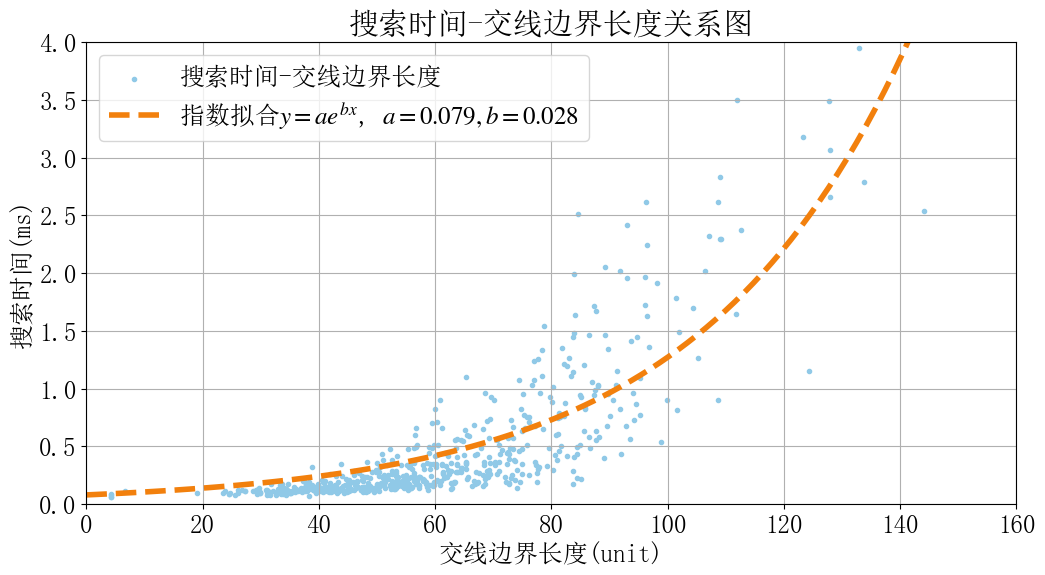

In [166]:

plt.figure(figsize=(12, 6))
axes = plt.axes()
axes.set_xlim(0, 160)
axes.set_ylim(0, 4)
plt.grid(True)

######### Data Selection
name = "perf_gcs_rand_corridor"
csv_file = ROOT_DIR + '/data/'+name+'.csv'
colnum = 3  # Total time
# colnum = 5  # Intersection time
# colnum = -1  # Astar time
#########

csv_plot.scatter(csv_file, 4, colnum, '.', "交线边界长度(unit)", "搜索时间(ms)", "搜索时间-交线边界长度关系图", "nan")

df = pd.read_csv(csv_file)
X = df.iloc[1:, 4]
Y = df.iloc[1:, colnum]

# fit the scatter using y = a * exp(b*x)
def func(x, a, b):
    return a * np.exp(b * x)
popt3, pcov3 = curve_fit(func, X.values , Y.values, (0.07,0.03))
print(popt3)
print(pcov3)

xs = np.linspace(0, 160, 100)
plt.plot(xs, func(xs, *popt3), label='fit: a=%5.3f, b=%5.3f' % tuple(popt3), 
         linestyle='--', color=(0.95, 0.5, 0.05), linewidth=4.0)

plt.legend(['搜索时间-交线边界长度', '指数拟合$y=a e^{bx}$, $a=%.3f, b=%.3f$' % tuple(popt3)], loc='upper left')
plt.savefig(csv_file.replace('.csv', '.png'), dpi=300)
plt.savefig(csv_file.replace('.csv', '.svg'), dpi=300,format="svg")
plt.savefig(csv_file.replace('.csv', '.pdf'), dpi=300,format="pdf")
plt.show()

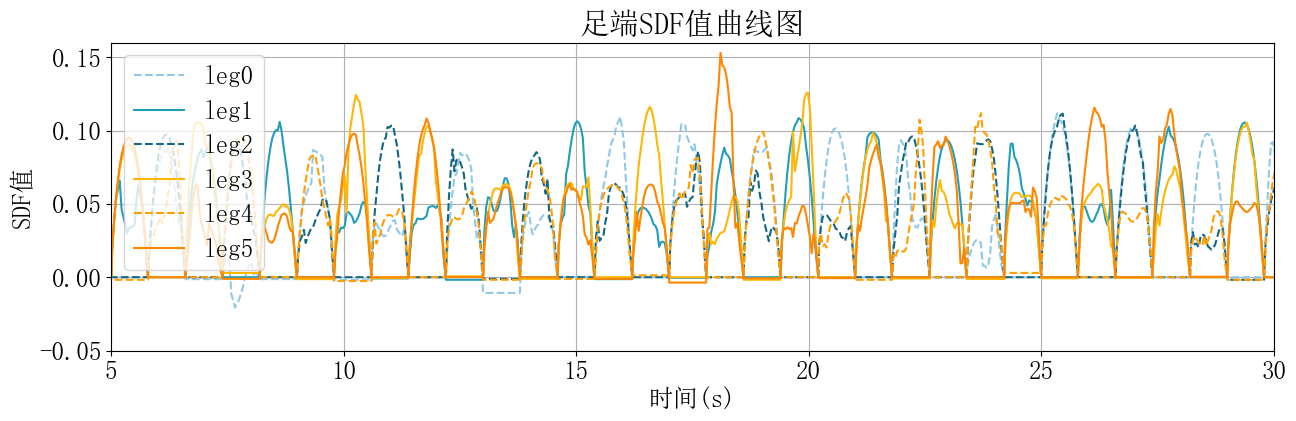

In [167]:
plt.figure(figsize=(15, 4))
axes = plt.axes()
axes.set_xlim(5, 30)
axes.set_ylim(-0.05, 0.16)
plt.grid(True)

######### Data Selection
name = "robotProfile2"
csv_file = ROOT_DIR + '/data/'+name+'.csv'
time_col = 0  # Time
sdf_col = 62  # SDF
leg_idx = 0
#########

for i in range(6):
    csv_plot.plot(csv_file, time_col, sdf_col+i, "时间(s)", "SDF值", "足端SDF值曲线图", "leg"+str(i))
plt.legend()
plt.savefig(ROOT_DIR + '/data/'+"sdf_curve"+'.pdf', dpi=300,format="pdf", bbox_inches='tight')

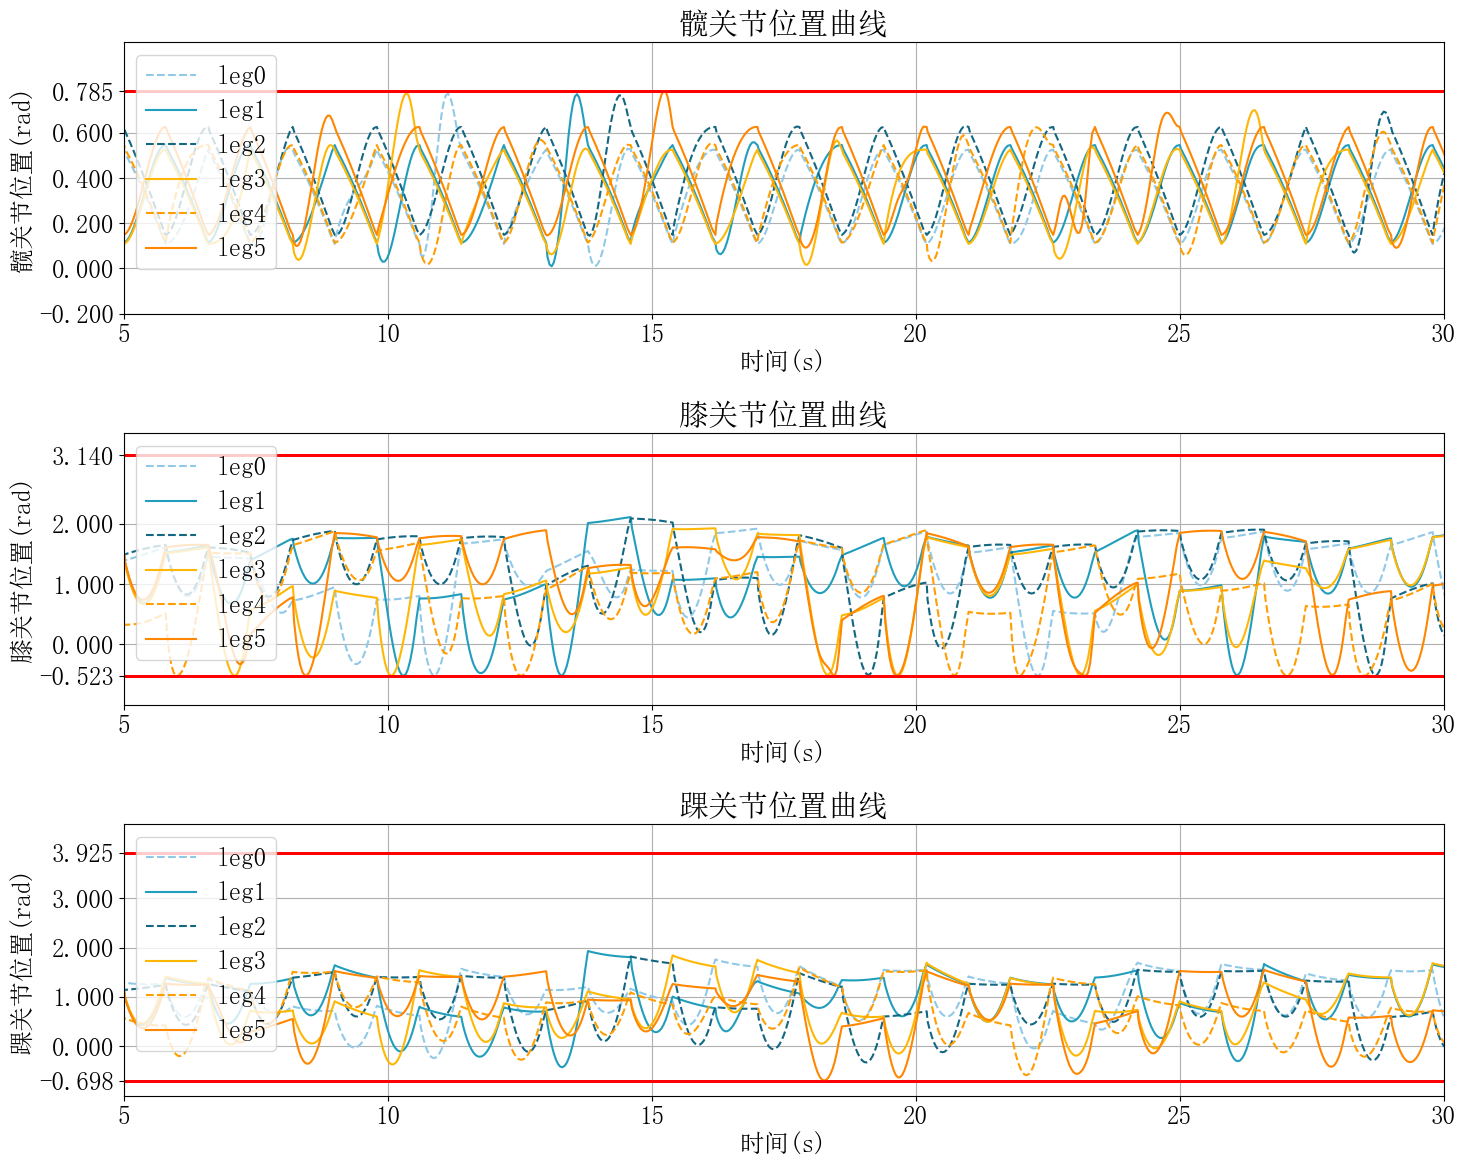

In [168]:
######### Data Selection
name = "robotProfile2"
csv_file = ROOT_DIR + '/data/'+name+'.csv'
time_col = 0  # Time
cfg_pos_col = 26  # cfg_pos
cfg_vel_col = 44  # cfg_vel (not used, this is not the real cfg_vel)
#########

col = cfg_pos_col

######### Figure setup
ylabel_list = ["髋关节位置(rad)", "膝关节位置(rad)", "踝关节位置(rad)"]
title_list = ["髋关节位置曲线", "膝关节位置曲线", "踝关节位置曲线"]
yticks_list = [[-0.2,0,0.2,0.4,0.6,0.785], [-0.5233, 0.0,1,2,3.14], [-0.6978,0,1,2,3,3.925]]
ylim_list = [[-0.2, 1], [-1, 3.5], [-1, 4.5]]
horizon_line_list = [((0.785, 0.785), (-0.785, -0.785)), ((3.14, 3.14), (-0.5233, -0.5233)), ((3.925, 3.925), (-0.6978, -0.6978))]

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
for i in range(3):
    axes[i].set_xlim(5, 30)
    axes[i].set_yticks(yticks_list[i])
    axes[i].set_ylim(ylim_list[i])
    axes[i].grid(True)

for joint_select in [[0], [1], [2]]:
    leg_select = [0,1,2,3,4,5]
    # joint_select = [0]
    for i in leg_select:
        for j in joint_select:
            csv_plot.plot(csv_file, time_col, col+i*3+j, "时间(s)", ylabel_list[j], title_list[j], "leg"+str(i), axes=axes[j])
            axes[j].plot([0, 100], horizon_line_list[j][0], 'r-',  linewidth=2.0)
            axes[j].plot([0, 100], horizon_line_list[j][1], 'r-',  linewidth=2.0)
            axes[j].legend(loc='upper left')

plt.tight_layout()
plt.savefig(ROOT_DIR + '/data/'+"joint_pos_curve"+'.pdf', dpi=300,format="pdf", bbox_inches='tight')

e:\Software\IDE\Anaconda3\envs\opencv\lib\site-packages\numpy\core\_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
e:\Software\IDE\Anaconda3\envs\opencv\lib\site-packages\numpy\core\_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)


maxtotTime:  8.76351
mintotTime:  0.085375
averageTotTime:  0.9230380298507462
maxnormalTime:  0.0333
minnormalTime:  0.001086
averagenormalTime:  0.0046151641791044775
maxcriticalTime:  8.75196
mincriticalTime:  0.084132
averagecriticalTime:  0.9184226940298509
maxminCostFunctional:  0.0185309
minminCostFunctional:  0.0140964
averageminCostFunctional:  nan


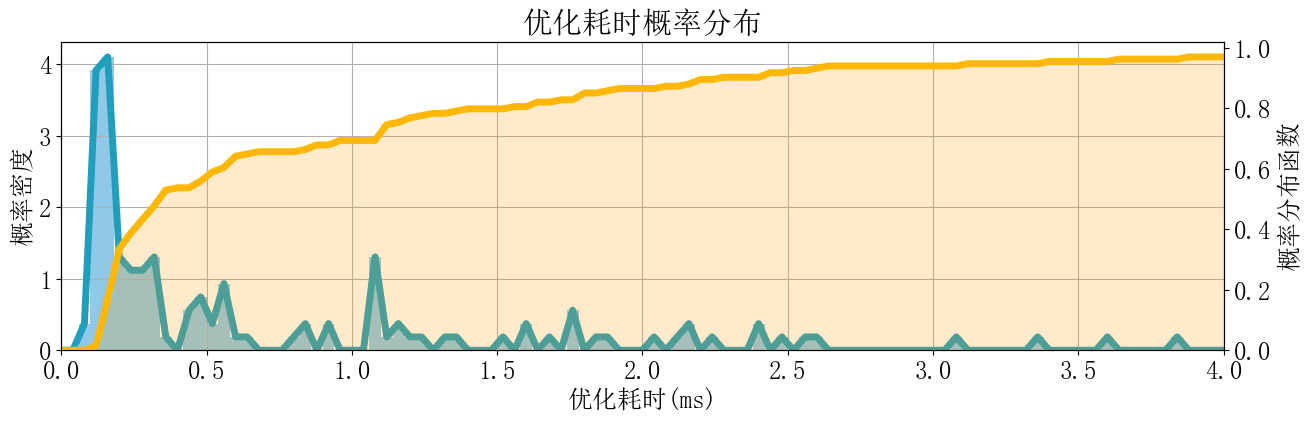

In [169]:


######### Data Selection
name = "optBenchmark2"
csv_file = ROOT_DIR + '/data/'+name+'.csv'
#########
df = pd.read_csv(csv_file)
normalTime = df.iloc[1:, 0].values
criticalTime = df.iloc[1:, 1].values
totTime = df.iloc[1:, 3].values
minCostFunctional = df.iloc[1:, 4].values

# replace inf with nan
for i in range(len(minCostFunctional)):
    minCostFunctional[i] = float(minCostFunctional[i])
    if minCostFunctional[i] == np.inf:
        minCostFunctional[i] = np.nan


maxtotTime = totTime.max()
mintotTime = totTime.min()
averageTotTime = totTime.mean()

maxnormalTime = normalTime.max()
minnormalTime = normalTime.min()
averagenormalTime = normalTime.mean()

maxcriticalTime = criticalTime.max()
mincriticalTime = criticalTime.min()
averagecriticalTime = criticalTime.mean()

maxminCostFunctional = minCostFunctional.max()
minminCostFunctional = minCostFunctional.min()
averageminCostFunctional = minCostFunctional.mean()

# print all
print("maxtotTime: ", maxtotTime)
print("mintotTime: ", mintotTime)
print("averageTotTime: ", averageTotTime)

print("maxnormalTime: ", maxnormalTime)
print("minnormalTime: ", minnormalTime)
print("averagenormalTime: ", averagenormalTime)

print("maxcriticalTime: ", maxcriticalTime)
print("mincriticalTime: ", mincriticalTime)
print("averagecriticalTime: ", averagecriticalTime)

print("maxminCostFunctional: ", maxminCostFunctional)
print("minminCostFunctional: ", minminCostFunctional)
print("averageminCostFunctional: ", averageminCostFunctional)



time_range = (0, 4)
resolution = 100
time_res = np.linspace(time_range[0], time_range[1], resolution+1)
cnt = np.zeros(resolution+1)
for i in range(len(totTime)):
    for j in range(resolution):
        if totTime[i] >= time_res[j] and totTime[i] < time_res[j+1]:
            cnt[j] += 1
            break
cnt_accum = np.zeros(resolution+1)
for i in range(resolution):
    cnt_accum[i+1] = cnt_accum[i] + cnt[i]
# time distribution
plt.figure(figsize=(15, 4))
axes = plt.axes()
axes.set_xlim(time_range[0], time_range[1])
# axes.set_ylim(-0.05, 0.16)
plt.grid(True)        

axes.set_ylabel("概率密度")
axes.bar(time_res[:], cnt/len(totTime)/(time_range[1]-time_range[0])*resolution, width=0.04, align='center', color=color_list[0], alpha=1)
axes.plot(time_res[:], cnt/len(totTime)/(time_range[1]-time_range[0])*resolution, '-', linewidth=5.0, color=color_list[1])
ax2 = axes.twinx()
ax2.set_ylabel("概率分布函数")
ax2.plot(time_res[:], cnt_accum/len(totTime), '-', linewidth=5.0, color=color_list[3])
ax2.bar(time_res[:], cnt_accum/len(totTime), width=0.04, align='center', color=color_list[4], alpha=0.2)

axes.set_xlabel("优化耗时(ms)")
axes.set_title("优化耗时概率分布")
plt.savefig(ROOT_DIR + '/data/'+"opt_time_cosume"+'.pdf', dpi=300,format="pdf", bbox_inches='tight')

## Misc

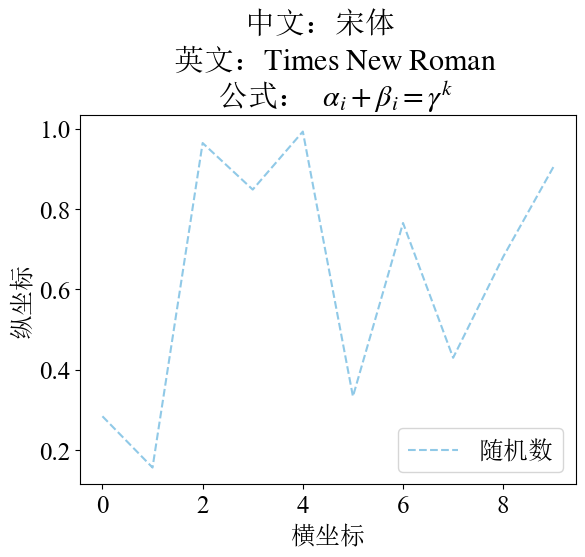

In [170]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

config = {
    "font.family":'serif',
    "font.size": 18,
    "mathtext.fontset":'stix',
    "font.serif": ['SimSun'],
}
rcParams.update(config)

x = np.random.random((10,))


plt.plot(x,label='随机数')
plt.title('中文：宋体 \n 英文：$\mathrm{Times \; New \; Roman}$ \n 公式： $\\alpha_i + \\beta_i = \\gamma^k$')
plt.xlabel('横坐标')
plt.ylabel('纵坐标')
plt.legend()
plt.yticks(fontproperties='Times New Roman', size=18)
plt.xticks(fontproperties='Times New Roman', size=18)
plt.show()


In [171]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
np.exp(a * b)

array([5.45981500e+01, 2.20264658e+04, 6.56599691e+07])